#  Medical Insurance Cost Predictor

## Overview
This project predicts individual medical insurance charges based on demographic 
and lifestyle features such as age, BMI, smoking status, and region.

The dataset contains 1338 records with 7 features. Multiple regression models 
were trained and compared to identify the best performing model for deployment

## Tech Stack
`Python` `Pandas` `Scikit-learn` `XGBoost` `Flask` `Docker` `Matplotlib` `Seaborn`

### IMPORTING DEPENDENCIES ###

In [333]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor

### DATA COLLECTION AND ANALYSIS ###

In [334]:
#loading the data from csv file to dataframe
df = pd.read_csv("/kaggle/input/datasets/aditixlg/medical-cost/insurance.csv")

In [335]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [336]:
# no. of row and columns
df.shape

(1338, 7)

In [337]:
#some info about dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


#### Catogerical Features: Sex , Smoker , Region ####

In [338]:
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [339]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


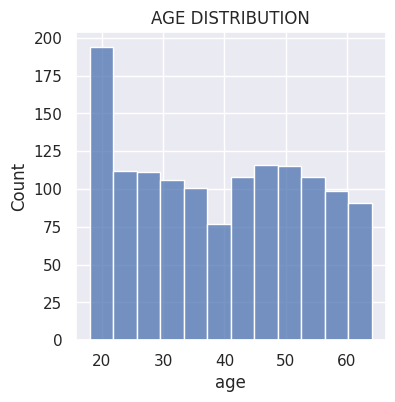

Average Age = 39.21 years


In [340]:
#AGE VALUE DISTRIBUTION
sns.set()
plt.figure(figsize = (4,4))
sns.histplot(df['age'])
plt.title('AGE DISTRIBUTION')
plt.show()
avg_age = df['age'].mean()
print("Average Age =", round(avg_age, 2), "years")

#### Average age is around 40 Years ####

/tmp/ipykernel_58/1239571135.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x = 'sex' , data = df, palette=['pink','grey'])


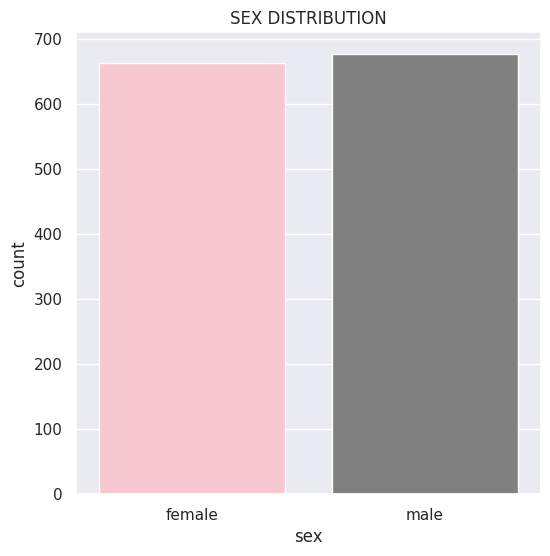

sex
male      676
female    662
Name: count, dtype: int64

In [341]:
#GENERAL COLUMN
plt.figure(figsize = (6,6))
sns.countplot(x = 'sex' , data = df, palette=['pink','grey'])
plt.title('SEX DISTRIBUTION')
plt.show()
df['sex'].value_counts()

#### No. of males and females are almost equal ####

/tmp/ipykernel_58/709444524.py:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['bmi'])


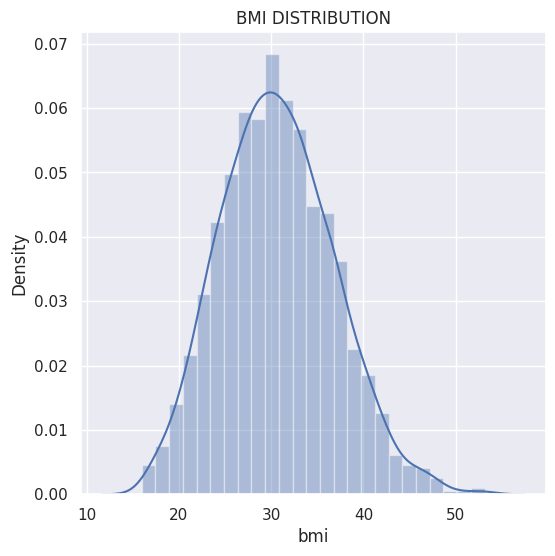

Average BMI = 30.66 years
Normal BMI 18 to 29 years


In [342]:
#BMI DISTRIBUTION
sns.set()
plt.figure(figsize = (6,6))
sns.distplot(df['bmi'])
plt.title('BMI DISTRIBUTION')
plt.show()
avg_bmi = df['bmi'].mean()
print("Average BMI =", round(avg_bmi, 2), "years")
print("Normal BMI 18 to 29 years")

 #### BMI is approximately normally distributed with an average of 30.66, which falls in the obese category ####

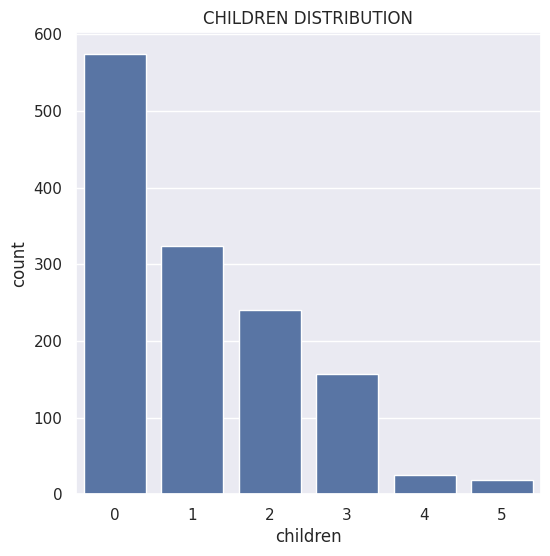

children
0    574
1    324
2    240
3    157
4     25
5     18
Name: count, dtype: int64

In [343]:
# CHILDREN COLUMN
plt.figure(figsize = (6,6))
sns.countplot(x = 'children' , data = df)
plt.title('CHILDREN DISTRIBUTION')
plt.show()
df['children'].value_counts()

/tmp/ipykernel_58/3189525373.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x = 'smoker' , data = df, palette=['pink','grey'])


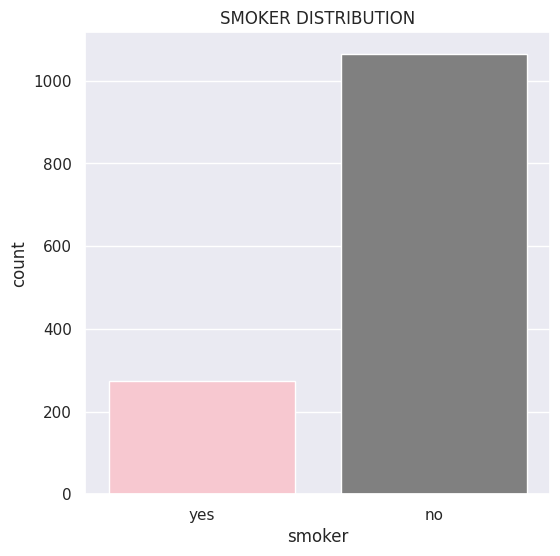

smoker : 274
Non-smoker : 1064


In [344]:
#SMOKER COLUMN 
plt.figure(figsize = (6,6))
sns.countplot(x = 'smoker' , data = df, palette=['pink','grey'])
plt.title('SMOKER DISTRIBUTION')
plt.show()
smoker_count = df['smoker'].value_counts()
print("smoker :" ,smoker_count['yes'])
print("Non-smoker :" , smoker_count['no'] )

#### Only ~20% of insured individuals are smokers (274 out of 1338), yet smoking is expected to be the strongest predictor of high insurance charges — making it a low-frequency but high-impact feature in the model. ####

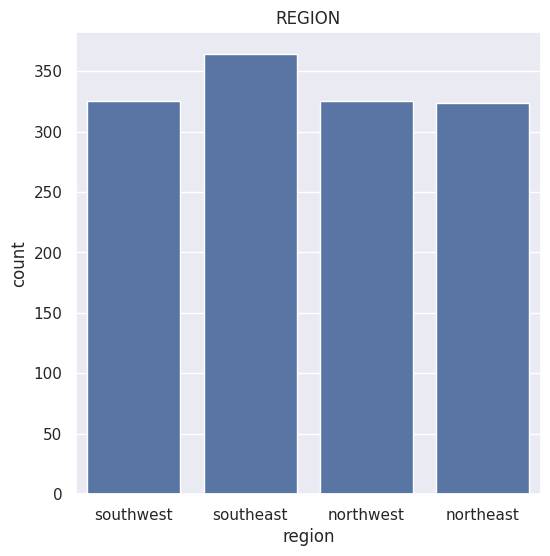

region
southeast    364
southwest    325
northwest    325
northeast    324
Name: count, dtype: int64

In [345]:
#REGION COLUMN
plt.figure(figsize =(6,6))
sns.countplot(x = 'region' ,data = df)
plt.title('REGION')
plt.show()
df['region'].value_counts()

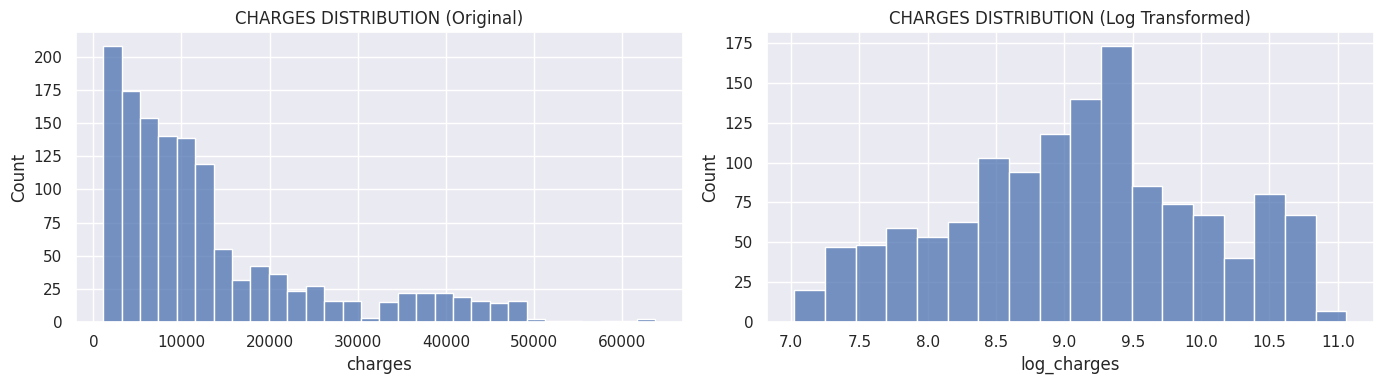

In [346]:

# DISTRIBUTION OF CHARGES
fig, axes = plt.subplots(1, 2, figsize=(14,4))

sns.histplot(df['charges'], ax=axes[0])
axes[0].set_title('CHARGES DISTRIBUTION (Original)')

df['log_charges'] = np.log1p(df['charges'])
sns.histplot(df['log_charges'], ax=axes[1])
axes[1].set_title('CHARGES DISTRIBUTION (Log Transformed)')

plt.tight_layout()
plt.show()



#### Original charges are heavily right-skewed with outliers beyond $60k. Log transformation compresses the tail into a near-normal distribution, making it a better target for regression. ####

## DATA PREPRPCESSING ##
 ### ENCODING CATEGORICAL DATA ####

In [347]:
# encoding sex column
df['sex'] = df['sex'].map({'male': 0, 'female': 1})
# encoding smoker column  
df['smoker'] = df['smoker'].map({'no': 0, 'yes': 1})
# encoding region column
df['region'] = df['region'].map({'southeast': 0, 'southwest': 1, 'northeast': 2, 'northwest': 3})

 ## SPLITTING FEATURE AND TARGET ##

In [348]:
Y= df['log_charges']
X = df.drop(['charges', 'log_charges'], axis=1)
print(X.columns) 

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region'], dtype='object')


In [349]:
X

,age,sex,bmi,children,smoker,region
0,19,1,27.900,0,1,1
1,18,0,33.770,1,0,0
2,28,0,33.000,3,0,0
3,33,0,22.705,0,0,3
4,32,0,28.880,0,0,3
...,...,...,...,...,...,...
1333,50,0,30.970,3,0,3
1334,18,1,31.920,0,0,2
1335,18,1,36.850,0,0,0
1336,21,1,25.800,0,0,1


In [350]:
Y

0        9.734236
1        7.453882
2        8.400763
3        9.998137
4        8.260455
          ...    
1333     9.268755
1334     7.699381
1335     7.396847
1336     7.605365
1337    10.279948
Name: log_charges, Length: 1338, dtype: float64

 ### SPLITTING IN TRAINING AND TESTING DATA ### 

In [351]:
x_train,x_test,y_train,y_test = train_test_split(X,Y,test_size = 0.2 , random_state  =42)

In [352]:
print(x.shape , x_train.shape , x_test.shape)

(1338, 7) (1070, 6) (268, 6)


 ### SCALING DATA ###

In [353]:
sr = StandardScaler()
x_train_scaled = sr.fit_transform(x_train)
x_test_scaled  = sr.transform(x_test)

In [354]:
models = {
    "LR": LinearRegression(),
    "DT": DecisionTreeRegressor(random_state=42),
    "RF": RandomForestRegressor(n_estimators=100, max_depth=7, random_state=42),
    "GB": GradientBoostingRegressor(n_estimators=100, random_state=42),
    "XGB": XGBRegressor(n_estimators=100, random_state=42, objective='reg:squarederror'),
    "SVR": SVR(),
    "KNN": KNeighborsRegressor(n_neighbors=5)
}

In [355]:
results = {}
for name, model in models.items():
    # Use scaled data for Linear Regression, SVR, KNN
    if name in ["LR", "SVR", "KNN"]:
        model.fit(x_train_scaled, y_train)
        y_pred = model.predict(x_test_scaled)
    else:
        model.fit(x_train, y_train)
        y_pred = model.predict(x_test)
    
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)
    
    results[name] = {"MAE": mae, "MSE": mse, "RMSE": rmse, "R2": r2}

In [356]:
result_df = pd.DataFrame(results).T
result_df.sort_values(by='R2', ascending=False)

,MAE,MSE,RMSE,R2
GB,0.184039,0.119894,0.346258,0.866614
SVR,0.158013,0.125241,0.353894,0.860666
RF,0.191136,0.129702,0.360142,0.855703
KNN,0.247843,0.167145,0.408834,0.814046
XGB,0.220552,0.168516,0.410507,0.812521
LR,0.272379,0.177808,0.421673,0.802184
DT,0.193111,0.205834,0.453689,0.771004


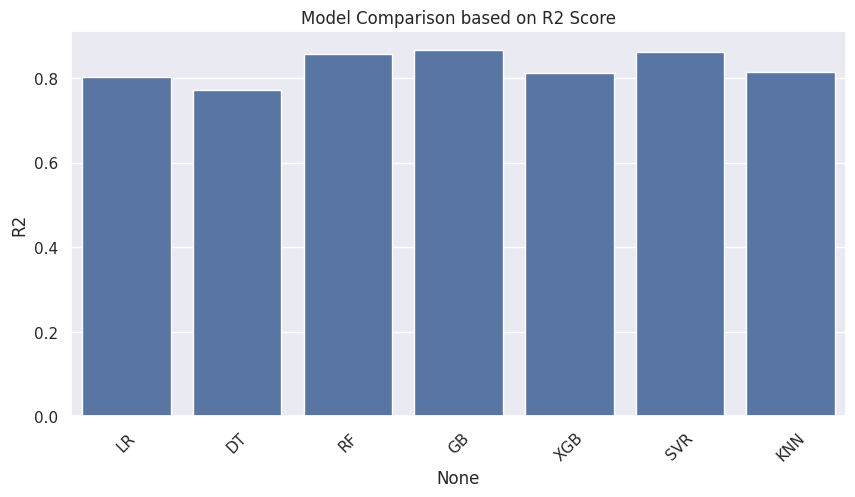

In [357]:
plt.figure(figsize=(10,5))
sns.barplot(x=result_df.index,y=result_df['R2'])
plt.title("Model Comparison based on R2 Score")
plt.xticks(rotation=45)
plt.show()

In [358]:
gradient_model = GradientBoostingRegressor(n_estimators=100, random_state=42)
gradient_model.fit(x_train, y_train)

GradientBoostingRegressor(random_state=42)

In [359]:
import pickle
pickle.dump(gradient_model, open('model.pkl', 'wb'))
pickle.dump(sr, open('scaler.pkl', 'wb'))

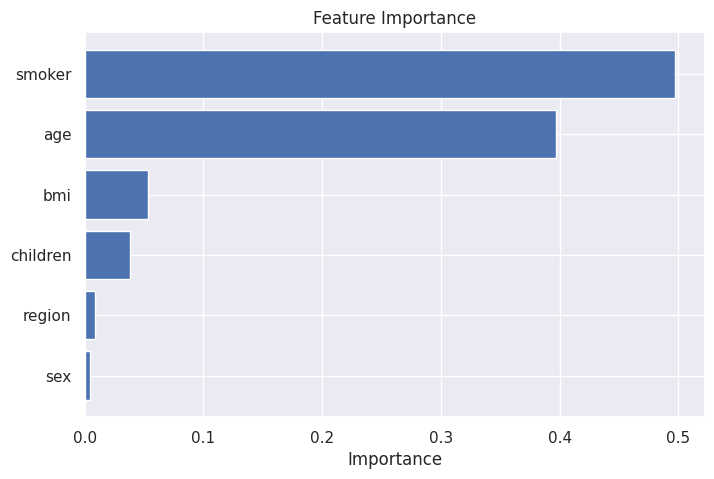

In [360]:
imp = gradient_model.feature_importances_
feature_df = pd.DataFrame({
    'Feature': ['age', 'sex', 'bmi', 'children', 'smoker', 'region'],
    'Importance': imp
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(8,5))
plt.barh(feature_df['Feature'], feature_df['Importance'])
plt.title('Feature Importance')
plt.xlabel('Importance')
plt.gca().invert_yaxis()
plt.show()